In [137]:
import shap
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc, roc_auc_score, classification_report

In [138]:
sns.set_theme(style="whitegrid", palette="Greys_r")
plt.rcParams["figure.figsize"] = (12, 6)   
plt.rcParams["figure.dpi"] = 100

red_grey = mcolors.LinearSegmentedColormap.from_list(
    "RedGrey",
    ["#bfbfbf96", "#c60f0f"]  
)

# Extract 

### Datos

In [139]:
df = pd.read_csv("dataset_modelado_final.csv") 
df

,id_hogar,cve_municipio,municipio,pa_mediana_remesa,pa_media_remesa,pa_desv_remesa,pa_cv_remesa,pa_pendiente_24m,pa_pendiente_norm,pa_n_meses_sin_envio,...,pc_iim_dp2,pc_pct_viv_remesas,pc_pct_viv_emigrantes,pc_imn_2020,pc_escolaridad_promedio_mun,pc_pct_pob_ocupada_2sm,pc_score_regional,pc_sub_capacidad_pago,pc_sub_intensidad_migratoria,default_12m
0,H000001,14001,Acatic,419.80260,422.501261,98.712412,0.233638,2.990360,0.007123,1.0,...,61.87355,9.698208,3.85099,0.890939,7.29,66.098725,0.462267,0.355929,0.666032,0
1,H000002,14001,Acatic,462.37990,447.044609,112.415062,0.251463,0.544468,0.001178,1.0,...,61.87355,9.698208,3.85099,0.890939,7.29,66.098725,0.462267,0.355929,0.666032,0
2,H000003,14001,Acatic,396.26960,424.600829,111.381945,0.262322,-0.261379,-0.000660,0.0,...,61.87355,9.698208,3.85099,0.890939,7.29,66.098725,0.462267,0.355929,0.666032,0
3,H000004,14001,Acatic,425.30190,424.737900,85.778142,0.201955,-4.654266,-0.010943,1.0,...,61.87355,9.698208,3.85099,0.890939,7.29,66.098725,0.462267,0.355929,0.666032,0
4,H000005,14001,Acatic,603.86795,598.866825,162.981997,0.272151,5.823873,0.009644,0.0,...,61.87355,9.698208,3.85099,0.890939,7.29,66.098725,0.462267,0.355929,0.666032,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,H009996,14124,Zapotlanejo,586.66880,616.506278,222.563443,0.361008,4.178937,0.007123,1.0,...,61.80894,10.464466,2.93460,0.895359,7.86,68.623897,0.496545,0.434251,0.657706,0
9996,H009997,14124,Zapotlanejo,241.03500,265.017396,104.022534,0.392512,-0.136696,-0.000567,1.0,...,61.80894,10.464466,2.93460,0.895359,7.86,68.623897,0.496545,0.434251,0.657706,0
9997,H009998,14124,Zapotlanejo,240.54490,253.776383,88.041580,0.346926,-0.141339,-0.000588,1.0,...,61.80894,10.464466,2.93460,0.895359,7.86,68.623897,0.496545,0.434251,0.657706,0
9998,H009999,14124,Zapotlanejo,374.59730,375.997717,120.059977,0.319310,6.212381,0.016584,1.0,...,61.80894,10.464466,2.93460,0.895359,7.86,68.623897,0.496545,0.434251,0.657706,0


## Transform 

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_hogar                      10000 non-null  object 
 1   cve_municipio                 10000 non-null  int64  
 2   municipio                     10000 non-null  object 
 3   pa_mediana_remesa             10000 non-null  float64
 4   pa_media_remesa               10000 non-null  float64
 5   pa_desv_remesa                10000 non-null  float64
 6   pa_cv_remesa                  10000 non-null  float64
 7   pa_pendiente_24m              10000 non-null  float64
 8   pa_pendiente_norm             10000 non-null  float64
 9   pa_n_meses_sin_envio          10000 non-null  float64
 10  pa_max_racha_sin_envio        10000 non-null  float64
 11  pa_fuerza_estacional          10000 non-null  float64
 12  pa_antiguedad_meses           10000 non-null  float64
 13  pa

In [141]:
df.isnull().sum()

id_hogar                        0
cve_municipio                   0
municipio                       0
pa_mediana_remesa               0
pa_media_remesa                 0
pa_desv_remesa                  0
pa_cv_remesa                    0
pa_pendiente_24m                0
pa_pendiente_norm               0
pa_n_meses_sin_envio            0
pa_max_racha_sin_envio          0
pa_fuerza_estacional            0
pa_antiguedad_meses             0
pa_cuota_propuesta_mxn          0
pa_ratio_remesa_cuota           0
pb_edad                         0
pb_genero_F                     0
pb_n_dependientes               0
pb_escolaridad_ord              0
pb_vivienda_propia              0
pb_vivienda_rentada             0
pc_iim_dp2                      0
pc_pct_viv_remesas              0
pc_pct_viv_emigrantes           0
pc_imn_2020                     0
pc_escolaridad_promedio_mun     0
pc_pct_pob_ocupada_2sm          0
pc_score_regional               0
pc_sub_capacidad_pago           0
pc_sub_intensi

In [142]:
df.duplicated().sum()

np.int64(0)

In [143]:
len(df["municipio"].unique())

124

There's 125 municipies in Jalisco , Mex. 

## Load 

In [144]:
df = pd.read_csv("dataset_modelado_final.csv", index_col=0)

---

In [145]:
df = pd.read_csv("dataset_modelado_final.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [146]:

def plot_correlation(data: pd.DataFrame, cols: list[str]) -> None:
    """
    Plot a correlation heatmap for selected columns.

    Parameters
    ----------
    data : pd.DataFrame
        Full dataset.

    cols : list[str]
        List of columns to include in correlation analysis.

    Returns
    -------
    None
    """

    corr_matrix = data[cols].corr()

    plt.figure(figsize=(20, 12))

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="Greys",
        fmt=".2f",
        linewidths=0.5,
        cbar=True
    )

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()
    
    
def evaluate_model_with_shap(model, X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, model_name: str = "Modelo", top_n: int = 10, shap_sample: int = 1000) -> float:
    """
    Generate feature importance and SHAP explainability plots for a trained model.

    This function visualizes model interpretability using built-in
    feature importance (if available) and SHAP values to explain
    the contribution of each feature to model predictions.

    Parameters
    ----------
    model : object
        Trained model supporting SHAP TreeExplainer.
    X_train : pd.DataFrame
        Training feature matrix.
    y_train : pd.Series
        Training target labels.
    X_test : pd.DataFrame
        Testing feature matrix used for SHAP analysis.
    y_test : pd.Series
        Testing target labels.
    model_name : str, optional
        Name of the model displayed in plots.
    top_n : int, optional
        Number of top features displayed in plots.
    shap_sample : int, optional
        Maximum number of samples used for SHAP computation.

    Returns
    -------
    float
        SHAP explainability process completed successfully.
    """

    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.feature_importances_
        }).sort_values("importance")

        imp.tail(top_n).plot.barh(x="feature", y="importance", figsize=(8,6))
        plt.title("Model Feature Importance")
        plt.grid(True)
        plt.show()

    print("\nCalculating SHAP values...")

    X_shap = X_test.sample(min(shap_sample, len(X_test)), random_state=42).astype(float)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(
        shap_values,
        X_shap,
        plot_type="bar",
        max_display=top_n
    )
    
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_shap,
        plot_type="dot",
        max_display=top_n
    )
    plt.title("SHAP Impact (Global)")
    plt.show()
    

def plot_global_shap_multiclass(raw_shap, X: pd.DataFrame, top_n: int = 10, class_names: tuple[str, str, str] = ("Class 0","Class 1","Class 2")) -> None:
    """
    Plot global SHAP feature importance for a multiclass model.

    This visualization aggregates mean absolute SHAP values and
    displays them as a stacked bar chart showing contribution
    per class.

    Parameters
    ----------
    raw_shap : array-like or list
        Raw SHAP values returned by the explainer.
    X : pd.DataFrame
        Dataset used for SHAP computation.
    top_n : int
        Number of top features displayed.
    class_names : tuple
        Names of the classes.
    """
    if isinstance(raw_shap, list):
        shap_array = np.stack(raw_shap, axis=2)
    else:
        shap_array = raw_shap

    mean_abs = np.mean(np.abs(shap_array), axis=0)


    if mean_abs.ndim == 1:
        total_importance = mean_abs
    else:
        total_importance = mean_abs.sum(axis=1)
        
    top_idx = np.argsort(total_importance)[-top_n:]

    features = X.columns[top_idx]
    values = mean_abs[top_idx]

    plt.figure(figsize=(12, 6))

    if values.ndim == 1:
        plt.barh(features, values)


    plt.xlabel("mean(|SHAP value|) (average impact magnitude)")
    plt.title("Global Feature Importance" )
    plt.tight_layout()
    plt.show()



def shap_multiclass_full_report(model, X: pd.DataFrame, class_names: tuple[str, str] = ("Denied", "Approved"), top_n: int = 10, sample_size: int = 1000) -> None:
    """
    Generate a complete SHAP explainability report.

    This function computes SHAP values and displays local/global
    interpretability plots for binary or multiclass classification models.

    Parameters
    ----------
    model : object
        Trained tree-based model compatible with SHAP TreeExplainer.
    X : pd.DataFrame
        Feature matrix used for SHAP computation.
    class_names : tuple[str, str], optional
        Names of the target classes displayed in plots.
    top_n : int, optional
        Number of top features displayed in plots.
    sample_size : int, optional
        Number of observations sampled for SHAP computation.

    Returns
    -------
    None
        Displays SHAP explainability plots.
    """


    X_shap = X.sample(min(sample_size, len(X)), random_state=42).astype(float)

    explainer = shap.TreeExplainer(model)
    raw_shap = explainer.shap_values(X_shap)

    if isinstance(raw_shap, np.ndarray):

        for i, name in enumerate(class_names):

            if name.lower() == "denied":
                shap_values = -raw_shap
            else:
                shap_values = raw_shap

            fig, axes = plt.subplots(
                1, 2,
                figsize=(12, 6),
                gridspec_kw={"width_ratios": [2,1]}
            )

            fig.suptitle(f"Class: {name}", fontsize=12, fontweight="bold")

            # Impact
            plt.sca(axes[0])
            shap.summary_plot(
                shap_values,
                X_shap,
                plot_type="dot",
                max_display=top_n,
                cmap=red_grey,
                show=False
            )
            axes[0].set_title("SHAP Impact", fontsize=9)

            plt.sca(axes[1])
            shap.summary_plot(
                shap_values,
                X_shap,
                plot_type="bar",
                max_display=top_n,
                color="#6e6e6e",
                show=False
            )

            axes[1].set_yticklabels([])
            axes[1].set_ylabel("")
            axes[1].set_title("Feature Importance", fontsize=9)
            
            fig.set_size_inches(12,6)

            plt.tight_layout()
            plt.show()

        return

    plt.figure(figsize=(12,6))
    plot_global_shap_multiclass(raw_shap, X_shap, top_n=top_n, class_names=class_names)
    
def plot_probability_density(y_test: pd.Series | np.ndarray, proba: np.ndarray, model_name: str = "Modelo", class_names: tuple[str, str, str] = ("Denied","Approved")) -> None:
    """
    Plot kernel density estimation of predicted probabilities.

    This visualization shows how probability estimates differ
    across the true classes.

    Parameters
    ----------
    y_test : array-like
        True class labels.
    proba : np.ndarray
        Predicted class probabilities.
    model_name : str
        Model name used in the plot title.
    class_names : tuple
        Names of the classes.
    """
    y_test = np.array(y_test)

    plt.figure()

    if proba.ndim == 1:

        sns.kdeplot(
            proba[y_test == 0],
            fill=True,
            alpha=0.3,
            linewidth=2,
            label=class_names[0]
        )

        sns.kdeplot(
            proba[y_test == 1],
            fill=True,
            alpha=0.3,
            linewidth=2,
            label=class_names[1]
        )

    plt.title(f"Probability Density - {model_name}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_xgb_importance(model, X: pd.DataFrame, importance_type: str = "gain", top_n: int = 10) -> None:
    """
    Plot feature importance from an XGBoost model.

    The function extracts importance scores from the trained booster
    and displays the top features.

    Parameters
    ----------
    model : XGBoost model
        Trained XGBoost classifier or regressor.
    X : pd.DataFrame
        Dataset used for training (needed for feature names).
    importance_type : str
        Importance metric used by XGBoost (e.g., "gain", "weight", "cover").
    top_n : int
        Number of most important features displayed.
    """
    booster = model.get_booster()
    score = booster.get_score(importance_type=importance_type)

    imp = pd.DataFrame({
        "feature": list(score.keys()),
        "importance": list(score.values())
    })

    if all(f.startswith("f") for f in imp["feature"]):
        feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
        imp["feature"] = imp["feature"].map(feature_map)

    imp = imp.sort_values("importance").tail(top_n)

    plt.figure(figsize=(12,6))
    plt.barh(imp["feature"], imp["importance"])
    plt.xlabel(f"XGBoost Importance ({importance_type})")
    plt.title(f"Top {top_n} Features - {importance_type}")
    plt.tight_layout()
    plt.show()
    
def plot_correlation_2(cols: pd.DataFrame) -> None:
    """
    Plot a correlation heatmap.

    This function computes the Pearson correlation matrix
    and visualizes pairwise correlations among variables.

    Parameters
    ----------
    cols : pd.DataFrame
        DataFrame containing numerical variables.

    Returns
    -------
    None
        Displays the correlation heatmap.
    """

    corr_matrix = cols.corr()

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="Greys",     
        fmt=".2f",
        linewidths=0.5,
        cbar=True
    )

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [147]:
df.keys()

Index(['id_hogar', 'cve_municipio', 'municipio', 'pa_mediana_remesa',
       'pa_media_remesa', 'pa_desv_remesa', 'pa_cv_remesa', 'pa_pendiente_24m',
       'pa_pendiente_norm', 'pa_n_meses_sin_envio', 'pa_max_racha_sin_envio',
       'pa_fuerza_estacional', 'pa_antiguedad_meses', 'pa_cuota_propuesta_mxn',
       'pa_ratio_remesa_cuota', 'pb_edad', 'pb_genero_F', 'pb_n_dependientes',
       'pb_escolaridad_ord', 'pb_vivienda_propia', 'pb_vivienda_rentada',
       'pc_iim_dp2', 'pc_pct_viv_remesas', 'pc_pct_viv_emigrantes',
       'pc_imn_2020', 'pc_escolaridad_promedio_mun', 'pc_pct_pob_ocupada_2sm',
       'pc_score_regional', 'pc_sub_capacidad_pago',
       'pc_sub_intensidad_migratoria', 'default_12m'],
      dtype='object')

In [148]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['cve_municipio', 'pa_mediana_remesa', 'pa_media_remesa',
       'pa_desv_remesa', 'pa_cv_remesa', 'pa_pendiente_24m',
       'pa_pendiente_norm', 'pa_n_meses_sin_envio', 'pa_max_racha_sin_envio',
       'pa_fuerza_estacional', 'pa_antiguedad_meses', 'pa_cuota_propuesta_mxn',
       'pa_ratio_remesa_cuota', 'pb_edad', 'pb_genero_F', 'pb_n_dependientes',
       'pb_escolaridad_ord', 'pb_vivienda_propia', 'pb_vivienda_rentada',
       'pc_iim_dp2', 'pc_pct_viv_remesas', 'pc_pct_viv_emigrantes',
       'pc_imn_2020', 'pc_escolaridad_promedio_mun', 'pc_pct_pob_ocupada_2sm',
       'pc_score_regional', 'pc_sub_capacidad_pago',
       'pc_sub_intensidad_migratoria', 'default_12m'],
      dtype='object')

In [149]:
df.select_dtypes(include=["object", "string"]).columns

Index(['id_hogar', 'municipio'], dtype='object')

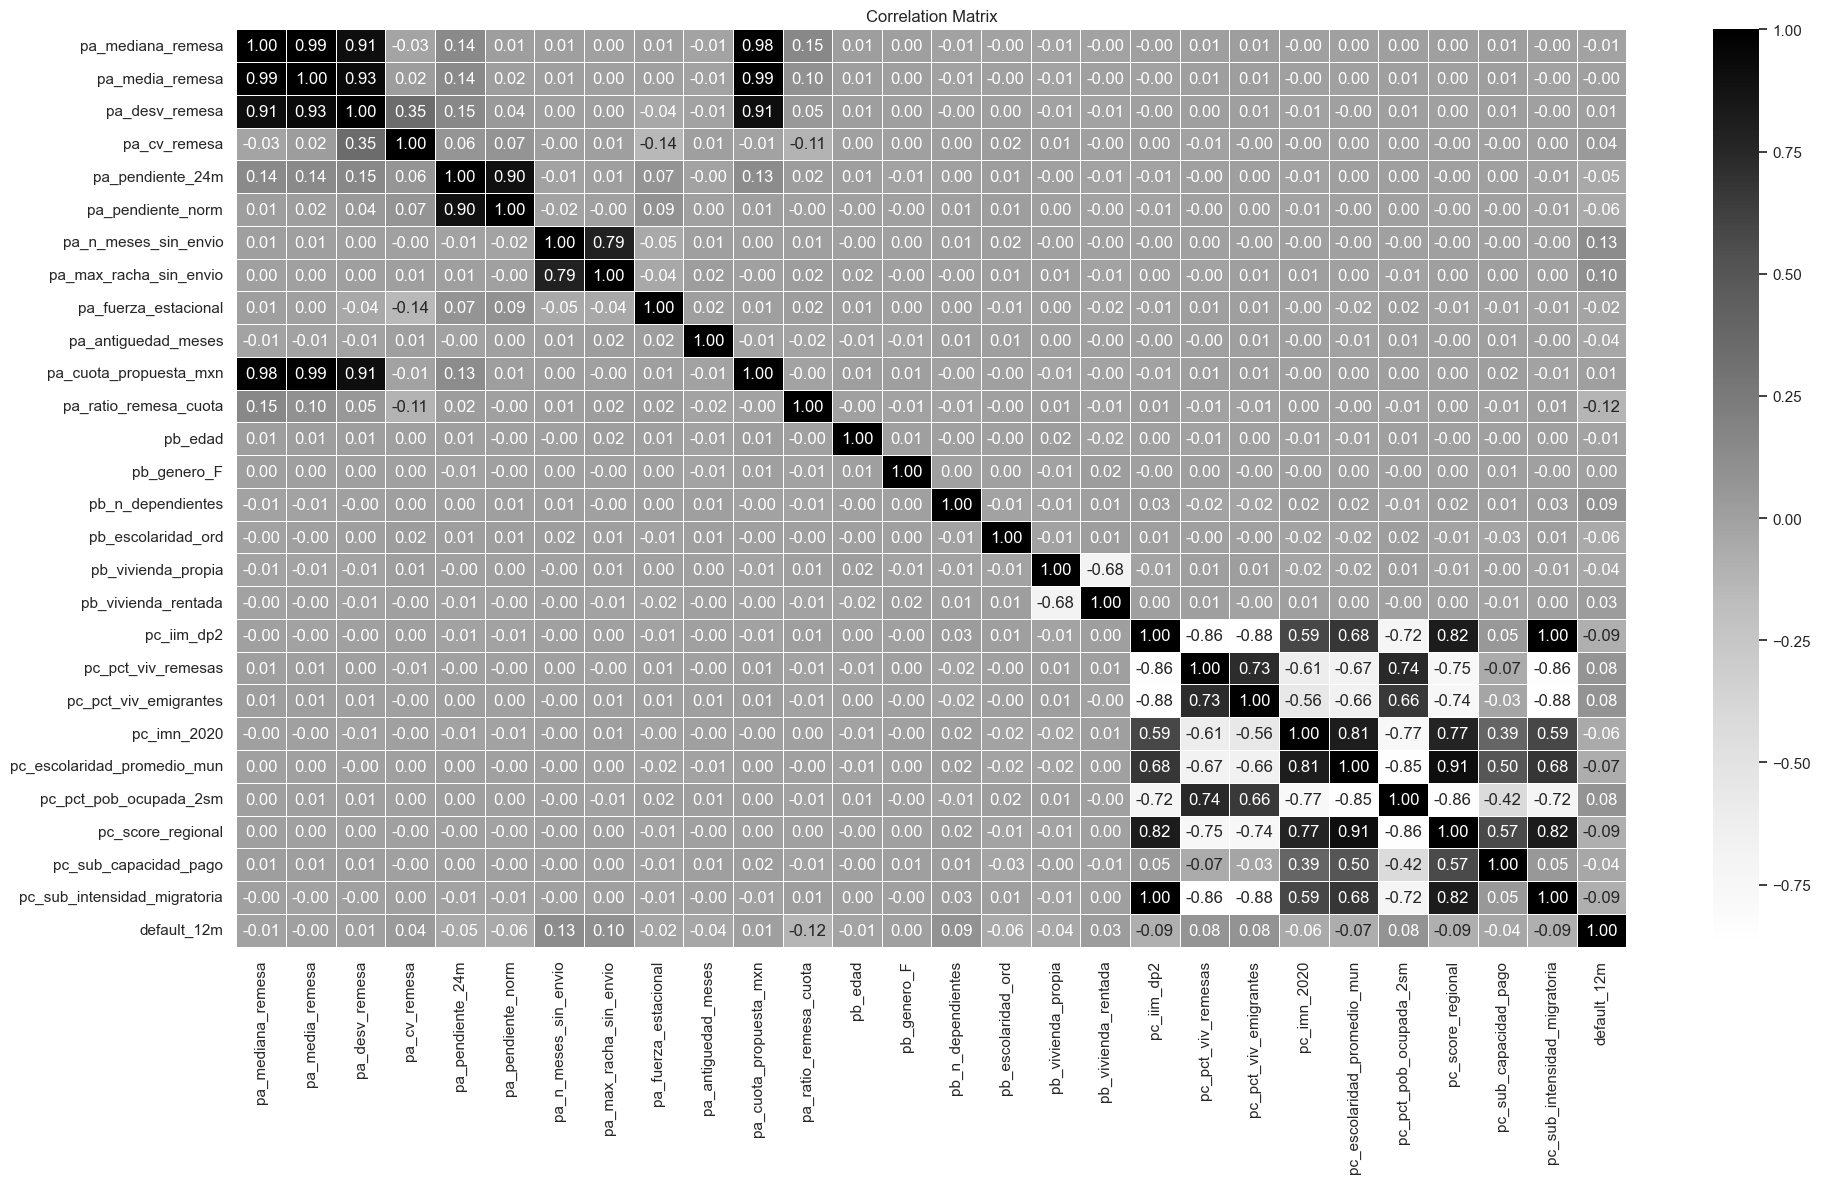

In [150]:
'''
cols = [
    "pa_media_remesa",
    "pa_cv_remesa",
    "pa_pendiente_norm",
    "pa_n_meses_sin_envio",
    "pa_max_racha_sin_envio",
    "pa_fuerza_estacional",
    "pa_antiguedad_meses",
    "pa_ratio_remesa_cuota",

    "pb_edad",
    "pb_genero_F",
    "pb_n_dependientes",
    "pb_escolaridad_ord",
    "pb_vivienda_propia",

    "pc_score_regional",
    "pc_sub_capacidad_pago"
]
'''

cols = ['pa_mediana_remesa', 'pa_media_remesa',
       'pa_desv_remesa', 'pa_cv_remesa', 'pa_pendiente_24m',
       'pa_pendiente_norm', 'pa_n_meses_sin_envio', 'pa_max_racha_sin_envio',
       'pa_fuerza_estacional', 'pa_antiguedad_meses', 'pa_cuota_propuesta_mxn',
       'pa_ratio_remesa_cuota', 'pb_edad', 'pb_genero_F', 'pb_n_dependientes',
       'pb_escolaridad_ord', 'pb_vivienda_propia', 'pb_vivienda_rentada',
       'pc_iim_dp2', 'pc_pct_viv_remesas', 'pc_pct_viv_emigrantes',
       'pc_imn_2020', 'pc_escolaridad_promedio_mun', 'pc_pct_pob_ocupada_2sm',
       'pc_score_regional', 'pc_sub_capacidad_pago',
       'pc_sub_intensidad_migratoria', 'default_12m']

plot_correlation(df, cols)

### Eliminando Coleanidad 

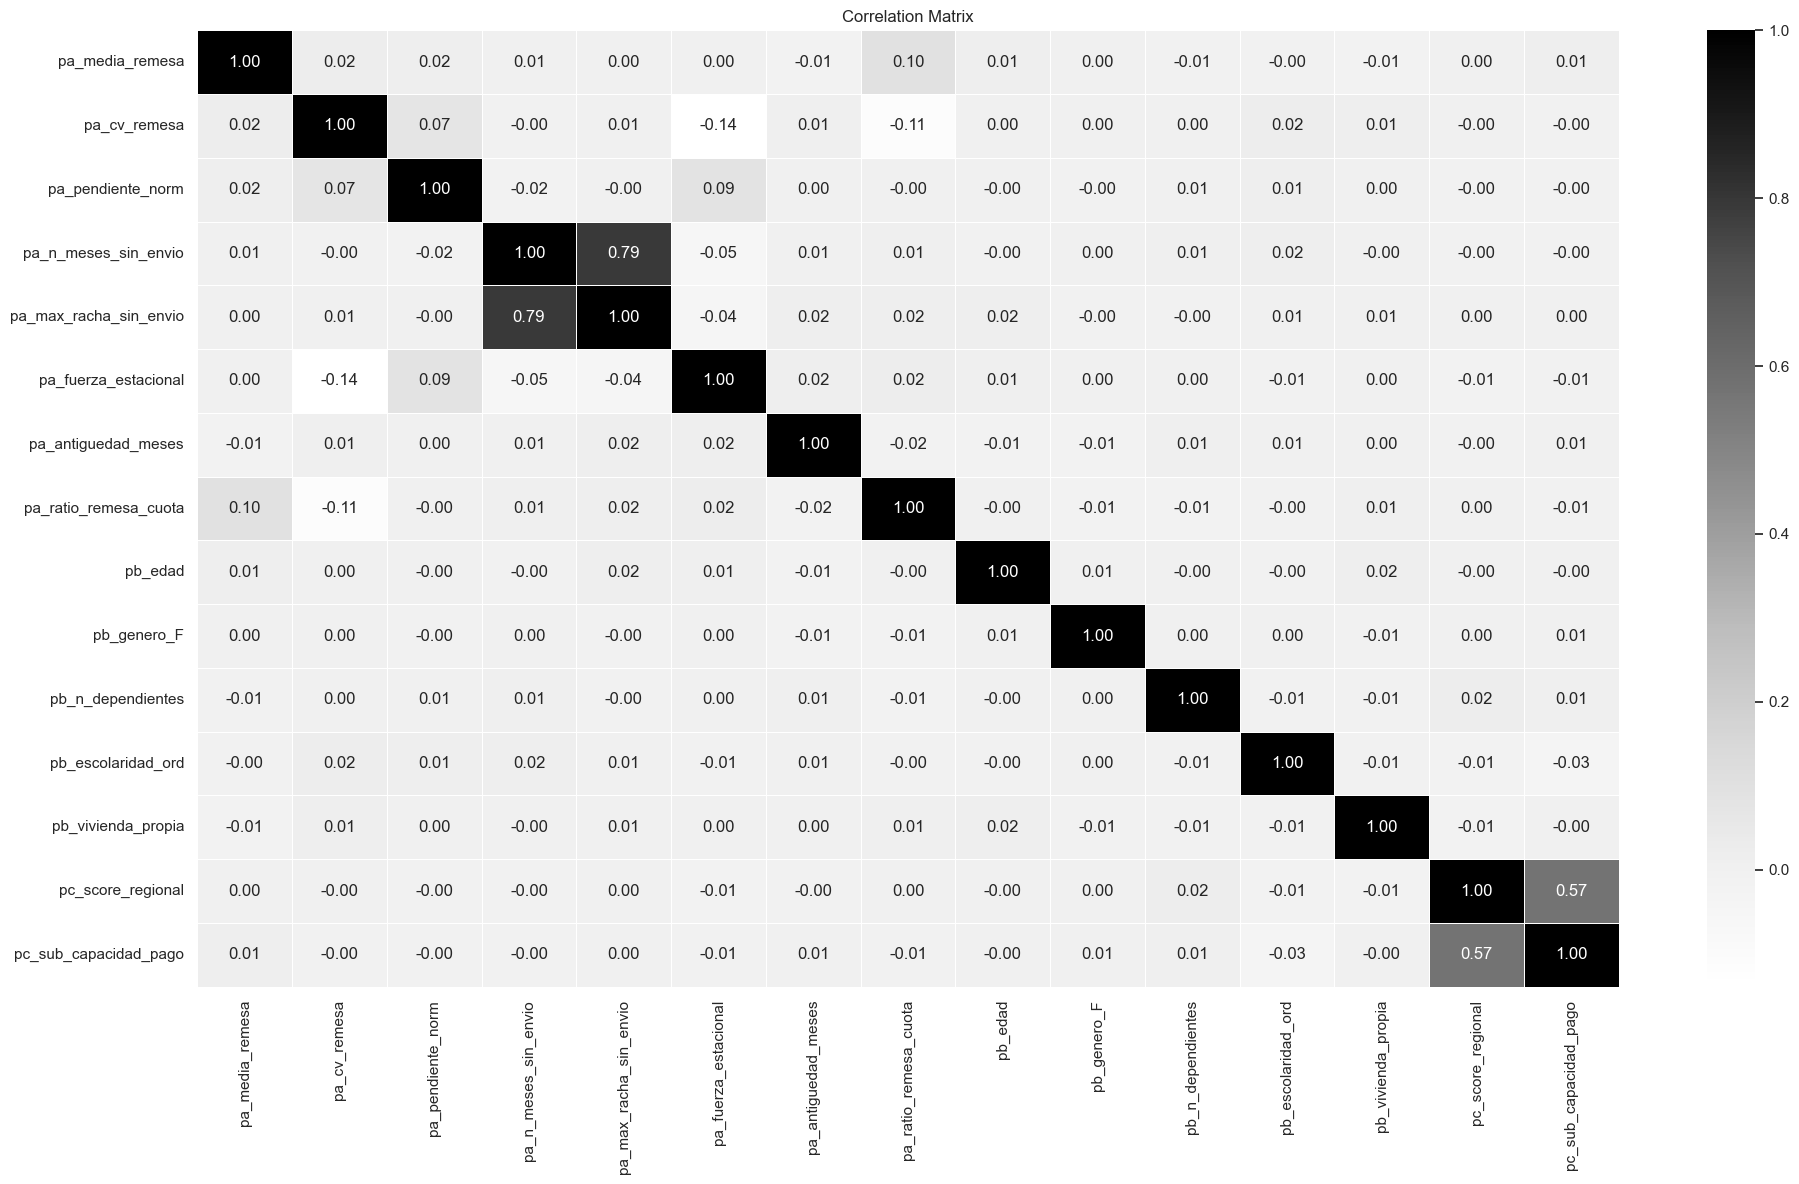

In [151]:
cols = [
    "pa_media_remesa",
    "pa_cv_remesa",
    "pa_pendiente_norm",
    "pa_n_meses_sin_envio",
    "pa_max_racha_sin_envio",
    "pa_fuerza_estacional",
    "pa_antiguedad_meses",
    "pa_ratio_remesa_cuota",

    "pb_edad",
    "pb_genero_F",
    "pb_n_dependientes",
    "pb_escolaridad_ord",
    "pb_vivienda_propia",

    "pc_score_regional",
    "pc_sub_capacidad_pago"
]


plot_correlation(df, cols)

In [152]:
y = df["default_12m"]

X = df.drop(columns=["default_12m"])

X = pd.get_dummies(X, drop_first=True).astype(float)

X.head()

,cve_municipio,pa_mediana_remesa,pa_media_remesa,pa_desv_remesa,pa_cv_remesa,pa_pendiente_24m,pa_pendiente_norm,pa_n_meses_sin_envio,pa_max_racha_sin_envio,pa_fuerza_estacional,...,municipio_Villa Hidalgo,municipio_Villa Purificación,municipio_Yahualica de González Gallo,municipio_Zacoalco de Torres,municipio_Zapopan,municipio_Zapotiltic,municipio_Zapotitlán de Vadillo,municipio_Zapotlanejo,municipio_Zapotlán del Rey,municipio_Zapotlán el Grande
0,14001.0,419.80260,422.501261,98.712412,0.233638,2.990360,0.007123,1.0,1.0,0.999995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,14001.0,462.37990,447.044609,112.415062,0.251463,0.544468,0.001178,1.0,1.0,0.983474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,14001.0,396.26960,424.600829,111.381945,0.262322,-0.261379,-0.000660,0.0,0.0,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,14001.0,425.30190,424.737900,85.778142,0.201955,-4.654266,-0.010943,1.0,1.0,0.846577,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14001.0,603.86795,598.866825,162.981997,0.272151,5.823873,0.009644,0.0,0.0,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [153]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 10150 entries, cve_municipio to municipio_Zapotlán el Grande
dtypes: float64(10150)
memory usage: 774.4 MB


In [ ]:
selected_features = [
    "pa_cv_remesa",
    "pa_pendiente_norm",
    "pa_n_meses_sin_envio",
    "pa_max_racha_sin_envio",
    "pa_fuerza_estacional",
    "pa_antiguedad_meses",
    "pa_ratio_remesa_cuota",

    "pb_edad",
    "pb_n_dependientes",
    "pb_escolaridad_ord",
    "pb_vivienda_propia",

    "pc_score_regional",
    "pc_sub_capacidad_pago"
]

# Features
X = X[selected_features]

X

,pa_cv_remesa,pa_pendiente_norm,pa_n_meses_sin_envio,pa_max_racha_sin_envio,pa_fuerza_estacional,pa_antiguedad_meses,pa_ratio_remesa_cuota,pb_edad,pb_n_dependientes,pb_escolaridad_ord,pb_vivienda_propia,pc_score_regional,pc_sub_capacidad_pago
0,0.233638,0.007123,1.0,1.0,0.999995,51.0,1.219477,49.0,1.0,3.0,1.0,0.462267,0.355929
1,0.251463,0.001178,1.0,1.0,0.983474,49.0,1.353074,33.0,2.0,1.0,1.0,0.462267,0.355929
2,0.262322,-0.000660,0.0,0.0,1.000000,88.0,1.120135,54.0,1.0,2.0,0.0,0.462267,0.355929
3,0.201955,-0.010943,1.0,1.0,0.846577,80.0,1.162696,56.0,1.0,4.0,0.0,0.462267,0.355929
4,0.272151,0.009644,0.0,0.0,1.000000,105.0,1.172335,22.0,2.0,4.0,1.0,0.462267,0.355929
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.361008,0.007123,1.0,1.0,0.604250,128.0,1.105933,43.0,1.0,4.0,0.0,0.496545,0.434251
9996,0.392512,-0.000567,1.0,1.0,0.855991,109.0,1.142331,76.0,4.0,2.0,1.0,0.496545,0.434251
9997,0.346926,-0.000588,1.0,1.0,0.403191,63.0,1.086761,47.0,4.0,2.0,1.0,0.496545,0.434251
9998,0.319310,0.016584,1.0,1.0,0.723824,53.0,1.251950,50.0,8.0,1.0,1.0,0.496545,0.434251


In [155]:
y.value_counts(normalize=True)

default_12m
0    0.9446
1    0.0554
Name: proportion, dtype: float64

In [156]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap_values_denied = -shap_values

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.98      0.75      0.85      1889
           1       0.14      0.68      0.23       111

    accuracy                           0.75      2000
   macro avg       0.56      0.71      0.54      2000
weighted avg       0.93      0.75      0.81      2000

AUC: 0.7794247397211929


In [157]:

train_proba = model.predict_proba(X_train)[:,1]
test_proba = model.predict_proba(X_test)[:,1]

print("Train AUC:", roc_auc_score(y_train, train_proba))
print("Test AUC:", roc_auc_score(y_test, test_proba))

Train AUC: 0.8353004748561049
Test AUC: 0.7794247397211929


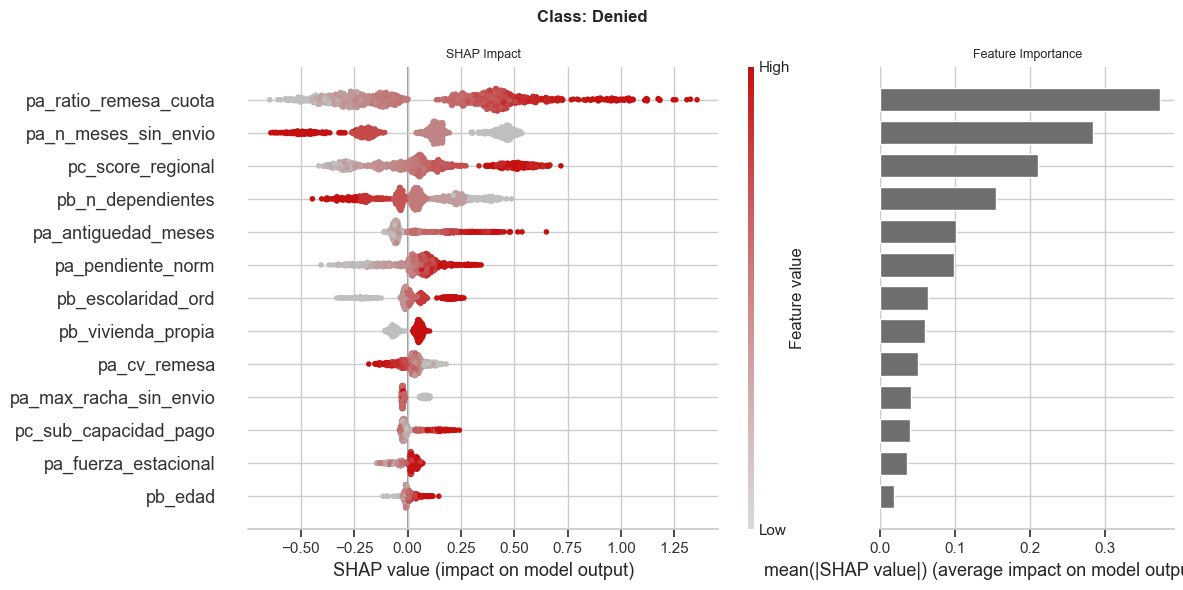

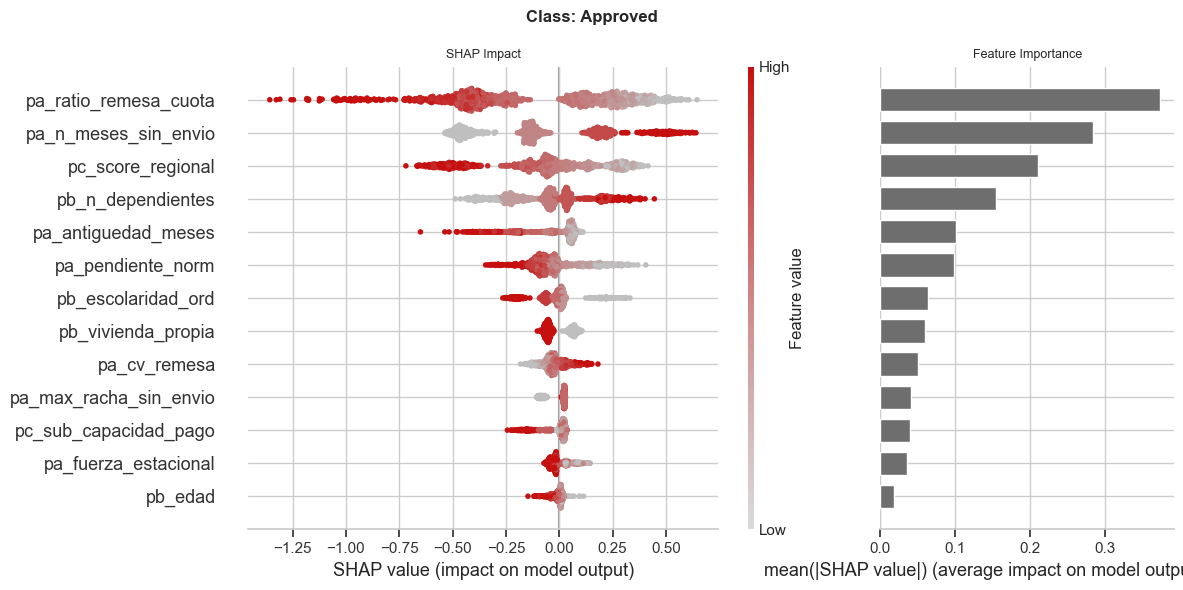

In [158]:
shap_multiclass_full_report(
    model=model,
    X=X_test,
    class_names=("Denied","Approved"),
    top_n=20,
    sample_size=1000,
)

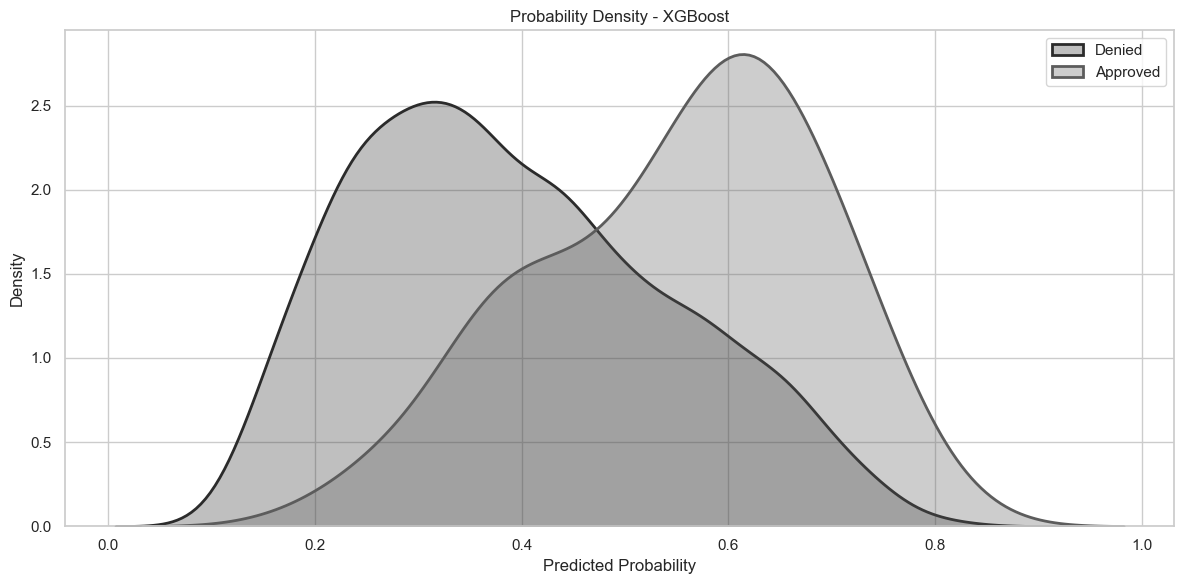

In [159]:
plot_probability_density(
    y_test,
    y_proba,
    model_name="XGBoost"
)

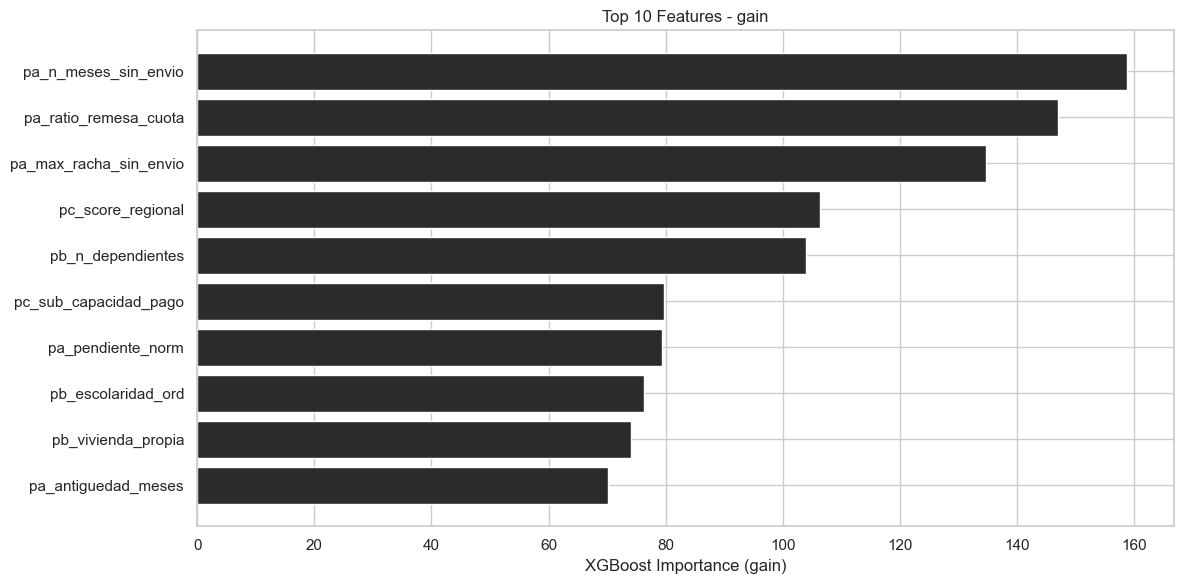

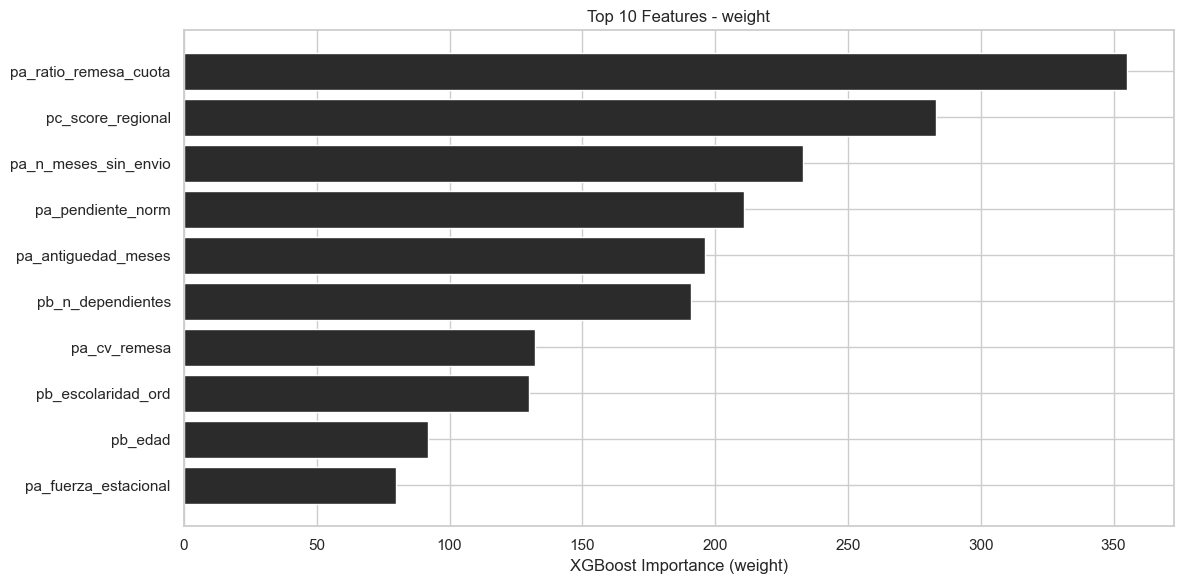

In [160]:
plot_xgb_importance(model, X_test, importance_type="gain")
plot_xgb_importance(model, X_test, importance_type="weight")

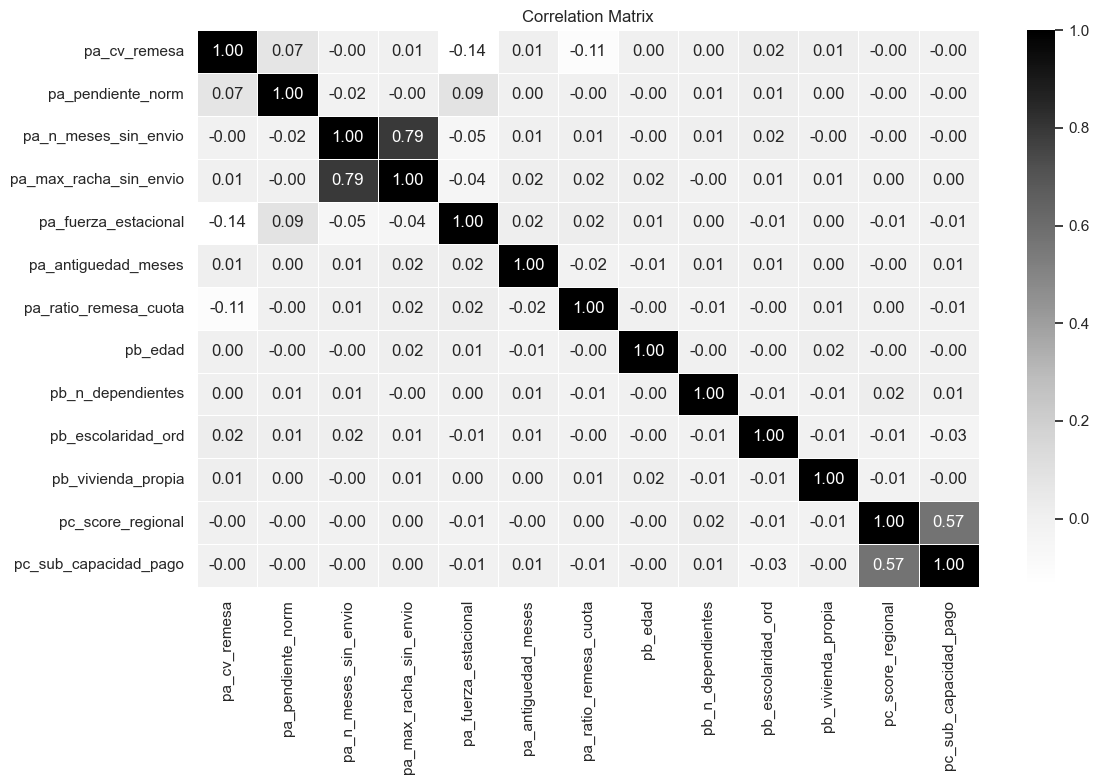

In [161]:

plot_correlation_2(cols=X[selected_features])

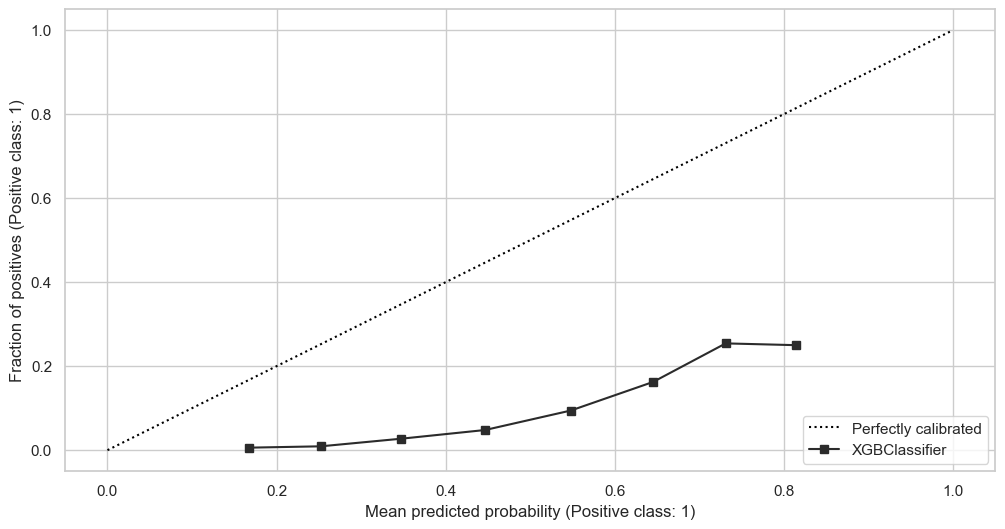

In [162]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    model,
    X_test,
    y_test,
    n_bins=10
)

In [163]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)
calibrated_proba = calibrated_model.predict_proba(X_test)[:,1]

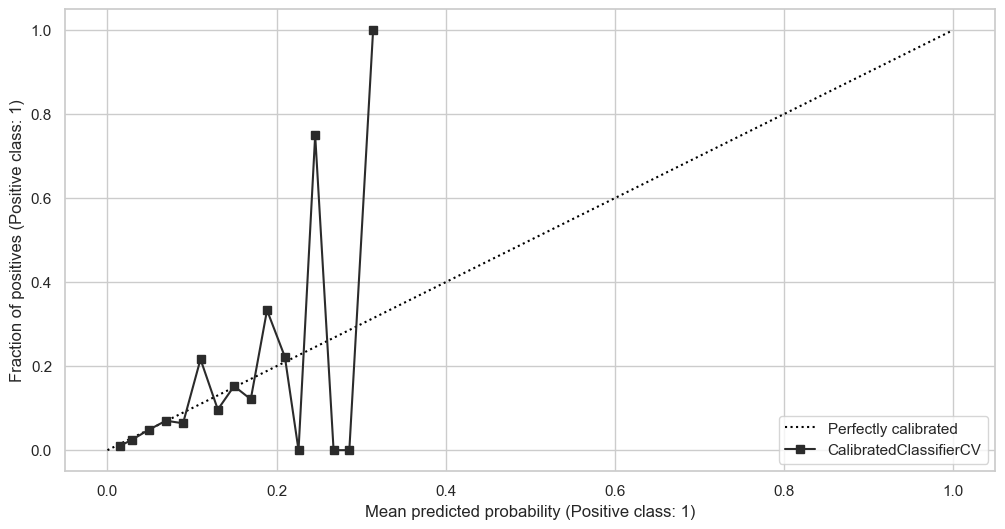

In [164]:
CalibrationDisplay.from_estimator(
    calibrated_model,
    X_test,
    y_test,
    n_bins=50
)

In [14]:
import pandas as pd 

df = pd.read_csv("results.csv", index_col=0)
df

,cve_municipio,municipio,pa_mediana_remesa,pa_media_remesa,pa_desv_remesa,pa_cv_remesa,pa_pendiente_24m,pa_pendiente_norm,pa_n_meses_sin_envio,pa_max_racha_sin_envio,...,pc_pct_pob_ocupada_2sm,pc_score_regional,pc_sub_capacidad_pago,pc_sub_intensidad_migratoria,default_12m,predicted_pd,expected_loss,decision,risk_bucket,interest_rate_model
id_hogar,,,,,,,,,,,,,,,,,,,,,
H000001,14001,Acatic,419.80260,422.501261,98.712412,0.233638,2.990360,0.007123,1.0,1.0,...,66.098725,0.462267,0.355929,0.666032,0,0.346984,11610.392431,1,"(0.345, 0.422]",0.325014
H000002,14001,Acatic,462.37990,447.044609,112.415062,0.251463,0.544468,0.001178,1.0,1.0,...,66.098725,0.462267,0.355929,0.666032,0,0.319434,10610.213048,1,"(0.266, 0.345]",0.312616
H000003,14001,Acatic,396.26960,424.600829,111.381945,0.262322,-0.261379,-0.000660,0.0,0.0,...,66.098725,0.462267,0.355929,0.666032,0,0.379635,13054.272704,1,"(0.345, 0.422]",0.339707
H000004,14001,Acatic,425.30190,424.737900,85.778142,0.201955,-4.654266,-0.010943,1.0,1.0,...,66.098725,0.462267,0.355929,0.666032,0,0.483287,17183.158774,0,"(0.422, 0.525]",0.386350
H000005,14001,Acatic,603.86795,598.866825,162.981997,0.272151,5.823873,0.009644,0.0,0.0,...,66.098725,0.462267,0.355929,0.666032,0,0.297750,14907.626634,1,"(0.266, 0.345]",0.302859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H009996,14124,Zapotlanejo,586.66880,616.506278,222.563443,0.361008,4.178937,0.007123,1.0,1.0,...,68.623897,0.496545,0.434251,0.657706,0,0.446154,23004.627882,0,"(0.422, 0.525]",0.369640
H009997,14124,Zapotlanejo,241.03500,265.017396,104.022534,0.392512,-0.136696,-0.000567,1.0,1.0,...,68.623897,0.496545,0.434251,0.657706,0,0.539758,11070.147188,0,"(0.525, 0.803]",0.411762
H009998,14124,Zapotlanejo,240.54490,253.776383,88.041580,0.346926,-0.141339,-0.000588,1.0,1.0,...,68.623897,0.496545,0.434251,0.657706,0,0.609550,13114.074725,0,"(0.525, 0.803]",0.443168


In [15]:
df.groupby("municipio")[["interest_rate_model", "predicted_pd"]].mean()

,interest_rate_model,predicted_pd
municipio,,
Acatic,0.372997,0.453613
Acatlán de Juárez,0.360950,0.426842
Ahualulco de Mercado,0.365286,0.436477
Amacueca,0.504892,0.746714
Amatitán,0.357563,0.419315
...,...,...
Zapotiltic,0.351377,0.405569
Zapotitlán de Vadillo,0.337461,0.374645
Zapotlanejo,0.362885,0.431143


In [12]:
df2 = pd.read_csv("results2.csv", index_col=0)
df2

,cve_municipio,municipio,pa_mediana_remesa,pa_media_remesa,pa_desv_remesa,pa_cv_remesa,pa_pendiente_24m,pa_pendiente_norm,pa_n_meses_sin_envio,pa_max_racha_sin_envio,...,pc_pct_pob_ocupada_2sm,pc_score_regional,pc_sub_capacidad_pago,pc_sub_intensidad_migratoria,default_12m,predicted_pd,expected_loss,decision,risk_bucket,interest_rate_model
id_hogar,,,,,,,,,,,,,,,,,,,,,
H000001,14001,Acatic,419.80260,422.501261,98.712412,0.233638,2.990360,0.007123,1.0,1.0,...,66.098725,0.462267,0.355929,0.666032,0,0.346984,0.0,1,"(0.345, 0.422]",0.280743
H000002,14001,Acatic,462.37990,447.044609,112.415062,0.251463,0.544468,0.001178,1.0,1.0,...,66.098725,0.462267,0.355929,0.666032,0,0.319434,0.0,1,"(0.266, 0.345]",0.268345
H000003,14001,Acatic,396.26960,424.600829,111.381945,0.262322,-0.261379,-0.000660,0.0,0.0,...,66.098725,0.462267,0.355929,0.666032,0,0.379635,0.0,1,"(0.345, 0.422]",0.295436
H000004,14001,Acatic,425.30190,424.737900,85.778142,0.201955,-4.654266,-0.010943,1.0,1.0,...,66.098725,0.462267,0.355929,0.666032,0,0.483287,0.0,0,"(0.422, 0.525]",0.342079
H000005,14001,Acatic,603.86795,598.866825,162.981997,0.272151,5.823873,0.009644,0.0,0.0,...,66.098725,0.462267,0.355929,0.666032,0,0.297750,0.0,1,"(0.266, 0.345]",0.258588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H009996,14124,Zapotlanejo,586.66880,616.506278,222.563443,0.361008,4.178937,0.007123,1.0,1.0,...,68.623897,0.496545,0.434251,0.657706,0,0.446154,0.0,0,"(0.422, 0.525]",0.325369
H009997,14124,Zapotlanejo,241.03500,265.017396,104.022534,0.392512,-0.136696,-0.000567,1.0,1.0,...,68.623897,0.496545,0.434251,0.657706,0,0.539758,0.0,0,"(0.525, 0.803]",0.367491
H009998,14124,Zapotlanejo,240.54490,253.776383,88.041580,0.346926,-0.141339,-0.000588,1.0,1.0,...,68.623897,0.496545,0.434251,0.657706,0,0.609550,0.0,0,"(0.525, 0.803]",0.398897


In [13]:
df2.groupby("municipio")[["interest_rate_model", "predicted_pd"]].mean()


,interest_rate_model,predicted_pd
municipio,,
Acatic,0.328726,0.453613
Acatlán de Juárez,0.316679,0.426842
Ahualulco de Mercado,0.321015,0.436477
Amacueca,0.460621,0.746714
Amatitán,0.313292,0.419315
...,...,...
Zapotiltic,0.307106,0.405569
Zapotitlán de Vadillo,0.293190,0.374645
Zapotlanejo,0.318614,0.431143
